<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.head())
print("Shape:", X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (364, 30)
Validation: (91, 30)
Test: (114, 30)


In [5]:
experiments = [
    {"hidden_layer_sizes": (10,), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (50,), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (100,), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (50,), "alpha": 0.01, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (50,), "alpha": 0.0001, "learning_rate_init": 0.01}
]

print("Number of experiments:", len(experiments))

Number of experiments: 5


In [6]:
results = []

for exp in experiments:
    model = MLPClassifier(
        hidden_layer_sizes=exp["hidden_layer_sizes"],
        alpha=exp["alpha"],
        learning_rate_init=exp["learning_rate_init"],
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append([
        exp["hidden_layer_sizes"],
        exp["alpha"],
        exp["learning_rate_init"],
        train_acc,
        val_acc,
        test_acc
    ])

print("All experiments completed!")

All experiments completed!


In [7]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Hidden Layers",
        "Alpha",
        "Learning Rate",
        "Train Accuracy",
        "Validation Accuracy",
        "Test Accuracy"
    ]
)

results_df

,Hidden Layers,Alpha,Learning Rate,Train Accuracy,Validation Accuracy,Test Accuracy
0,"(10,)",0.0001,0.001,0.991758,0.978022,0.964912
1,"(50,)",0.0001,0.001,0.997253,0.978022,0.973684
2,"(100,)",0.0001,0.001,1.000000,0.978022,0.947368
3,"(50,)",0.0100,0.001,0.997253,0.978022,0.964912
4,"(50,)",0.0001,0.010,1.000000,0.967033,0.956140


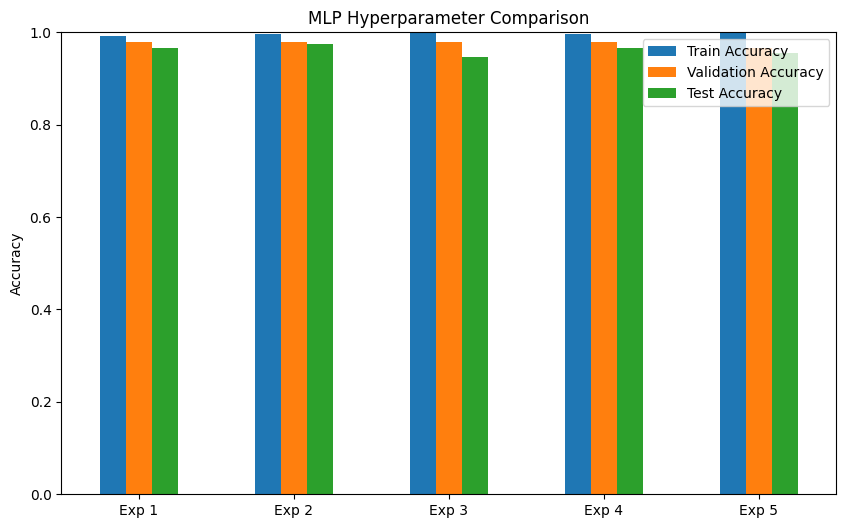

In [8]:
results_df[[
    "Train Accuracy",
    "Validation Accuracy",
    "Test Accuracy"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("MLP Hyperparameter Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(
    range(len(results_df)),
    [f"Exp {i+1}" for i in range(len(results_df))],
    rotation=0
)

plt.show()

In [9]:
best = results_df.loc[results_df["Test Accuracy"].idxmax()]

print("Best Hyperparameter Combination:")
print(best)

Best Hyperparameter Combination:
Hidden Layers             (50,)
Alpha                    0.0001
Learning Rate             0.001
Train Accuracy         0.997253
Validation Accuracy    0.978022
Test Accuracy          0.973684
Name: 1, dtype: object
